# Task 2: Hourly Pollutant Forecasting

Predict hourly pollutant concentrations for 6 station/pollutant/period combinations, assuming error-free measurements (instrument_status = 0 only for training).

All targets are true out-of-sample: each station's data ends exactly before the prediction period.

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.data.loader import load_series
from src.forecasting.train import (
    train_xgboost_direct, predict_direct, seasonal_naive_predict
)
from src.forecasting.evaluate import evaluate_predictions
from src.utils.constants import FORECAST_TARGETS

print(f"Forecast targets: {len(FORECAST_TARGETS)}")
for t in FORECAST_TARGETS:
    print(f"  Station {t['station_code']} / {t['item_name']} / {t['start']} to {t['end']}")

Forecast targets: 6
  Station 206 / so2 / 2023-07-01 to 2023-07-31 23:00:00
  Station 211 / no2 / 2023-08-01 to 2023-08-31 23:00:00
  Station 217 / o3 / 2023-09-01 to 2023-09-30 23:00:00
  Station 219 / co / 2023-10-01 to 2023-10-31 23:00:00
  Station 225 / pm10 / 2023-11-01 to 2023-11-30 23:00:00
  Station 228 / pm2.5 / 2023-12-01 to 2023-12-31 23:00:00


## Approach: Direct Prediction (no recursion)

**Why not recursive?** Recursive predictions over 720+ hours accumulate errors catastrophically — XGBoost with lag features performed 6-10x worse than a simple seasonal naive baseline in initial experiments.

**Direct prediction** uses only features that can be computed for any future datetime without knowing intermediate predictions:
- Temporal features (hour, day_of_week, month) with cyclical encoding
- Historical same-hour statistics (mean, std, median)
- Historical same-hour-and-day-of-week statistics
- Historical same-month-and-hour statistics

**Validation**: Hold out the last month of available data to simulate forward prediction.

In [2]:
results = []
all_predictions = {}

for target in FORECAST_TARGETS:
    sc = target["station_code"]
    ic = target["item_code"]
    name = target["item_name"]
    pred_start = target["start"]
    pred_end = target["end"]
    
    print(f"\n{'='*60}")
    print(f"Station {sc} / {name} | Predict: {pred_start} to {pred_end}")
    print(f"{'='*60}")
    
    # Load training data (normal status only, all data before prediction period)
    train_full = load_series(sc, ic, normal_only=True, end_before=pred_start)
    
    # Handle missing values: forward fill gaps in the time series
    train_reindexed = train_full[["clean_value"]].copy()
    full_idx = pd.date_range(train_reindexed.index.min(), train_reindexed.index.max(), freq="h")
    train_reindexed = train_reindexed.reindex(full_idx)
    train_reindexed["clean_value"] = train_reindexed["clean_value"].ffill().bfill()
    
    print(f"Training data: {len(train_reindexed)} hours ({train_reindexed.index.min()} to {train_reindexed.index.max()})")
    
    # --- Validation: hold out last month ---
    val_start = train_reindexed.index.max() - pd.DateOffset(months=1) + pd.Timedelta(hours=1)
    train_data = train_reindexed.loc[:val_start - pd.Timedelta(hours=1)]
    val_data = train_reindexed.loc[val_start:]
    val_index = val_data.index
    
    print(f"Validation period: {val_start.date()} to {val_data.index.max().date()} ({len(val_data)} hours)")
    
    # Baseline: Seasonal Naive
    naive_preds = seasonal_naive_predict(train_data, val_index)
    naive_metrics = evaluate_predictions(val_data["clean_value"], naive_preds)
    print(f"\nSeasonal Naive  — RMSE: {naive_metrics['rmse']:.5f}, MAE: {naive_metrics['mae']:.5f}")
    
    # XGBoost Direct
    model, stats = train_xgboost_direct(train_data)
    xgb_val_preds = predict_direct(model, val_index, stats)
    xgb_metrics = evaluate_predictions(val_data["clean_value"], xgb_val_preds)
    print(f"XGBoost Direct  — RMSE: {xgb_metrics['rmse']:.5f}, MAE: {xgb_metrics['mae']:.5f}")
    
    # --- Final prediction: retrain on all data, predict target period ---
    model_final, stats_final = train_xgboost_direct(train_reindexed)
    pred_index = pd.date_range(pred_start, pred_end, freq="h")
    final_preds = predict_direct(model_final, pred_index, stats_final)
    
    # Also generate naive for comparison
    naive_final = seasonal_naive_predict(train_reindexed, pred_index)
    
    print(f"\nFinal predictions generated: {len(final_preds)} hours")
    print(f"  XGBoost range: [{final_preds.min():.5f}, {final_preds.max():.5f}]")
    print(f"  Naive range:   [{naive_final.min():.5f}, {naive_final.max():.5f}]")
    
    # Choose best model based on validation
    best_model_name = "xgboost" if xgb_metrics["rmse"] < naive_metrics["rmse"] else "naive"
    best_final = final_preds if best_model_name == "xgboost" else naive_final
    print(f"  Best model: {best_model_name}")
    
    results.append({
        "station": sc,
        "pollutant": name,
        "period": f"{pred_start} to {pred_end}",
        "val_naive_rmse": round(naive_metrics["rmse"], 5),
        "val_naive_mae": round(naive_metrics["mae"], 5),
        "val_xgb_rmse": round(xgb_metrics["rmse"], 5),
        "val_xgb_mae": round(xgb_metrics["mae"], 5),
        "improvement_%": round((1 - xgb_metrics["rmse"] / naive_metrics["rmse"]) * 100, 1),
        "best_model": best_model_name,
    })
    
    all_predictions[f"{sc}_{name}"] = {
        "best": best_final,
        "xgboost": final_preds,
        "naive": naive_final,
        "val_actual": val_data["clean_value"],
        "val_xgboost": xgb_val_preds,
        "val_naive": naive_preds,
    }

print("\n\nAll targets processed.")


Station 206 / so2 | Predict: 2023-07-01 to 2023-07-31 23:00:00
Training data: 21864 hours (2021-01-01 00:00:00 to 2023-06-30 23:00:00)
Validation period: 2023-05-31 to 2023-06-30 (744 hours)



Seasonal Naive  — RMSE: 0.00156, MAE: 0.00130


XGBoost Direct  — RMSE: 0.00125, MAE: 0.00113



Final predictions generated: 744 hours
  XGBoost range: [0.00322, 0.00403]
  Naive range:   [0.00200, 0.00500]
  Best model: xgboost

Station 211 / no2 | Predict: 2023-08-01 to 2023-08-31 23:00:00
Training data: 22608 hours (2021-01-01 00:00:00 to 2023-07-31 23:00:00)
Validation period: 2023-07-01 to 2023-07-31 (744 hours)



Seasonal Naive  — RMSE: 0.01383, MAE: 0.01222


...

XGBoost Direct  — RMSE: 28.51326, MAE: 16.60026



Final predictions generated: 720 hours
  XGBoost range: [31.56708, 135.20955]
  Naive range:   [11.00000, 217.00000]
  Best model: xgboost

Station 228 / pm2.5 | Predict: 2023-12-01 to 2023-12-31 23:00:00
Training data: 25536 hours (2021-01-01 00:00:00 to 2023-11-30 23:00:00)
Validation period: 2023-10-31 to 2023-11-30 (744 hours)



Seasonal Naive  — RMSE: 14.28790, MAE: 10.60668


XGBoost Direct  — RMSE: 12.23066, MAE: 9.24599



Final predictions generated: 744 hours
  XGBoost range: [22.12103, 48.88739]
  Naive range:   [3.00000, 38.00000]
  Best model: xgboost


All targets processed.


## Results Summary

In [3]:
# Results table
results_df = pd.DataFrame(results)
print("Validation Results (last month holdout):")
print(results_df.to_string(index=False))

Validation Results (last month holdout):
 station pollutant                            period  val_naive_rmse  val_naive_mae  val_xgb_rmse  val_xgb_mae  improvement_% best_model
     206       so2 2023-07-01 to 2023-07-31 23:00:00         0.00156        0.00130       0.00125      0.00113           19.4    xgboost
     211       no2 2023-08-01 to 2023-08-31 23:00:00         0.01383        0.01222       0.00772      0.00648           44.1    xgboost
     217        o3 2023-09-01 to 2023-09-30 23:00:00         0.01532        0.01146       0.01481      0.01191            3.3    xgboost
     219        co 2023-10-01 to 2023-10-31 23:00:00         0.15791        0.13008       0.14767      0.11197            6.5    xgboost
     225      pm10 2023-11-01 to 2023-11-30 23:00:00        32.67010       24.58840      28.51326     16.60026           12.7    xgboost
     228     pm2.5 2023-12-01 to 2023-12-31 23:00:00        14.28790       10.60668      12.23066      9.24599           14.4    xgboost


## Visualization: Validation Period — Actual vs Predicted

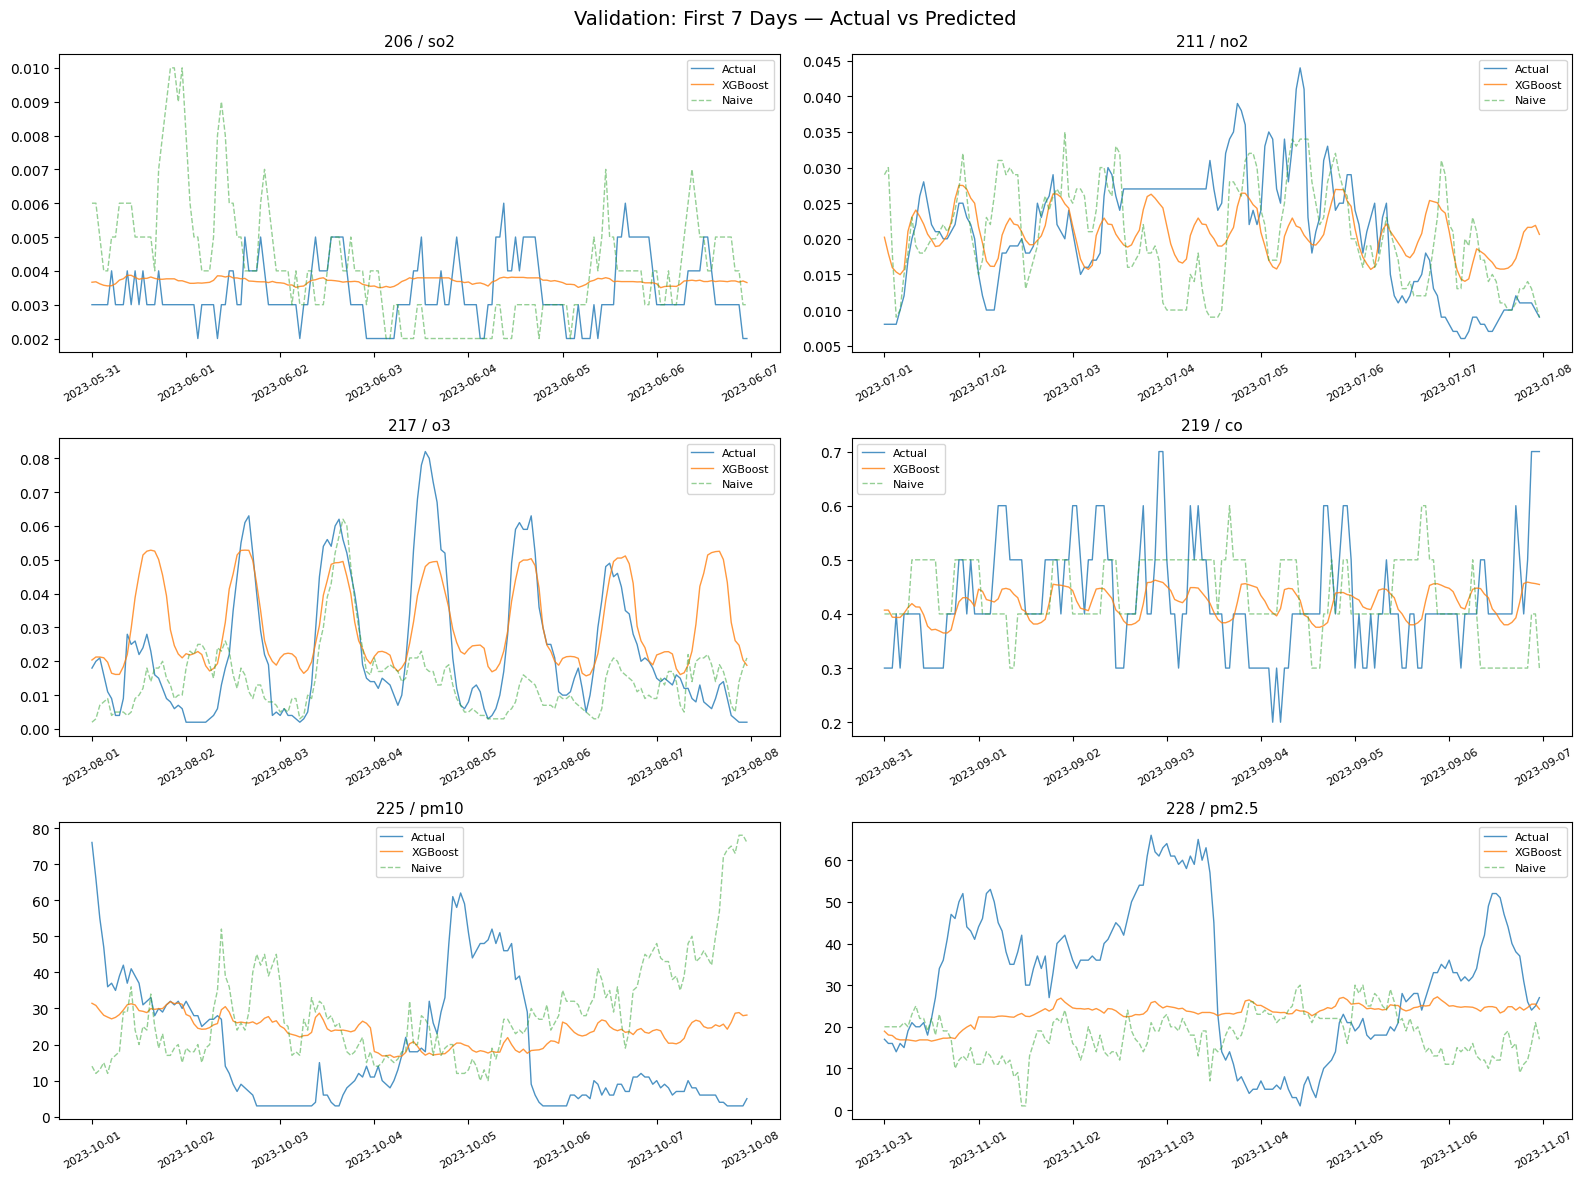

In [4]:
# Plot validation: actual vs predicted for each target
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (key, preds) in enumerate(all_predictions.items()):
    ax = axes[i]
    # Show first 7 days of validation for clarity
    n_show = min(168, len(preds["val_actual"]))
    actual = preds["val_actual"].iloc[:n_show]
    xgb = preds["val_xgboost"].iloc[:n_show]
    naive = preds["val_naive"].iloc[:n_show]
    
    ax.plot(actual.index, actual.values, label="Actual", linewidth=1, alpha=0.8)
    ax.plot(xgb.index, xgb.values, label="XGBoost", linewidth=1, alpha=0.8)
    ax.plot(naive.index, naive.values, label="Naive", linewidth=1, alpha=0.5, linestyle="--")
    ax.set_title(key.replace("_", " / "), fontsize=11)
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30, labelsize=8)

plt.suptitle("Validation: First 7 Days — Actual vs Predicted", fontsize=14)
plt.tight_layout()
plt.savefig("../outputs/forecast_validation.png", dpi=150, bbox_inches="tight")
plt.show()

## Export Final Predictions

In [5]:
# Export best predictions to CSV
import os
os.makedirs("../outputs", exist_ok=True)

all_exports = []
for target in FORECAST_TARGETS:
    key = f"{target['station_code']}_{target['item_name']}"
    preds = all_predictions[key]["best"]
    df = pd.DataFrame({
        "measurement_datetime": preds.index,
        "station_code": target["station_code"],
        "item_code": target["item_code"],
        "item_name": target["item_name"],
        "predicted_value": preds.values,
    })
    all_exports.append(df)

export_df = pd.concat(all_exports, ignore_index=True)
export_df.to_csv("../outputs/forecast_predictions.csv", index=False)
print(f"Exported {len(export_df)} predictions to outputs/forecast_predictions.csv")
print(f"\nPer-target counts:")
print(export_df.groupby(["station_code", "item_name"]).agg(
    count=("predicted_value", "count"),
    mean=("predicted_value", "mean"),
    min=("predicted_value", "min"),
    max=("predicted_value", "max"),
).to_string())

Exported 4416 predictions to outputs/forecast_predictions.csv

Per-target counts:
                        count       mean        min         max
station_code item_name                                         
206          so2          744   0.003559   0.003219    0.004030
211          no2          744   0.017790   0.008714    0.028320
217          o3           720   0.026105   0.015684    0.040241
219          co           744   0.466237   0.363401    0.644966
225          pm10         720  50.881104  31.567081  135.209549
228          pm2.5        744  28.225266  22.121025   48.887394
